Cache Types: ['fifo' 'lru' 'sieve' 'arc' 'gdsf']
Modes: ['never' 'oracle' 'ml']
Traces: ['cf_c' 'cf_d' 'cf_a' 'cf_e' 'cf_f' 'cf_g' 'cf_b' 'fb_a' 'cf_h' 'fb_b'
 'fb_c' 'wm_t']


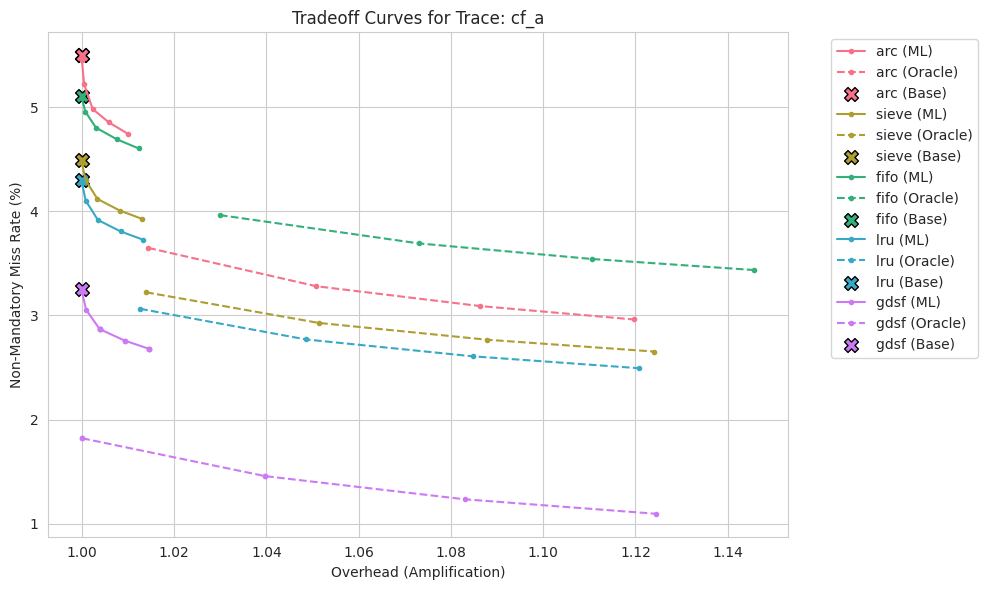

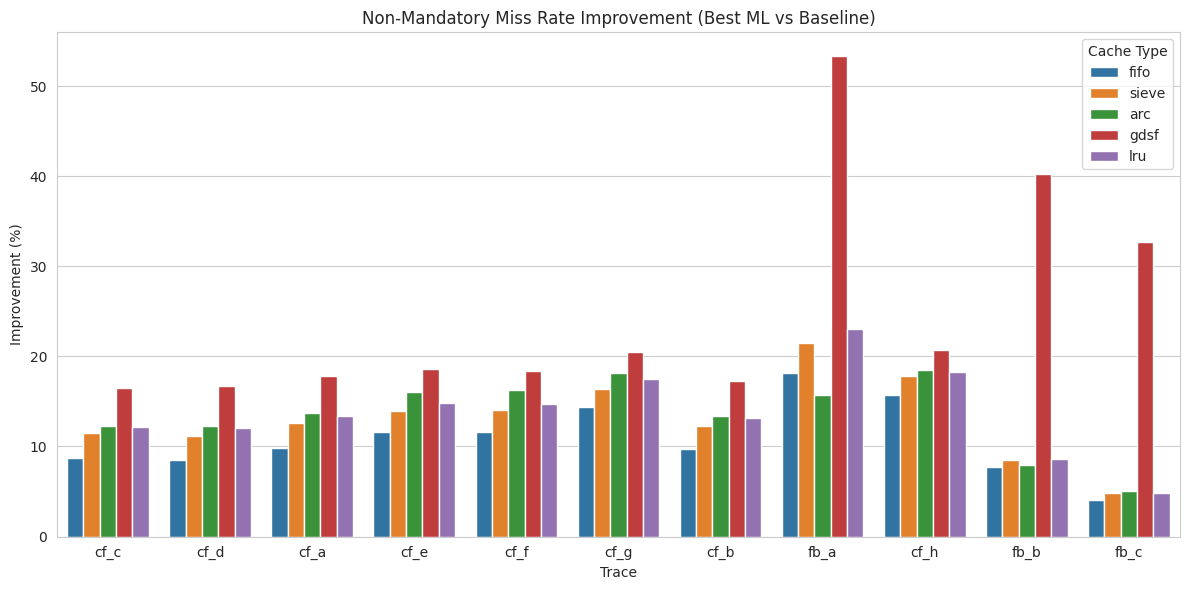

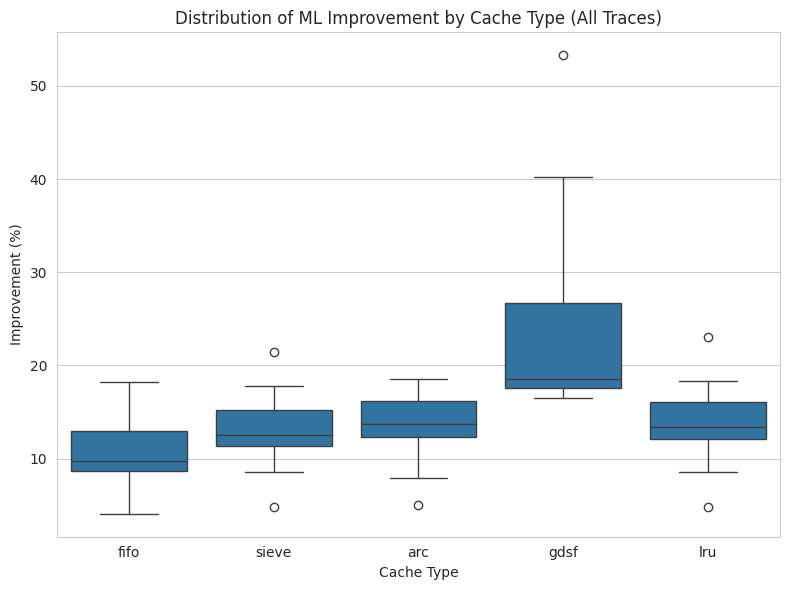

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
files = [
    '../results/r8i2_baseline.csv',
    '../results/r8i2_oracle.csv',
    '../results/r8i2_ml_cf_rfc.csv',
    '../results/r8i2_ml_fb_rfc.csv',
    #'../results/r8i2_ml_wm_rfc.csv', # Uncomment if available and needed
]

df = pd.concat([pd.read_csv(f) for f in files])

# Calculate metrics
# Non-mandatory miss rate (NMR)
df['miss_all'] = df['miss_mandatory'] + df['miss_expired'] + df['miss_evicted']
df['non_mandatory_misses'] = df['miss_all'] - df['miss_mandatory']
df['optmiss'] = df['non_mandatory_misses']
df['nmr'] = df['non_mandatory_misses'] / df['all'] * 100

# Amplification / Overhead
df['rv_pending'] = df['revals'] - df['hit_reval'] - df['reval_wasted']
denominator = df['miss_all'] + df['hit_reval']
denominator = denominator.replace(0, 1)

df['amp_lower'] = df['reval_wasted'] / denominator + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / denominator + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2

# Identify Cache Types and Modes
print("Cache Types:", df['cache_type'].unique())
print("Modes:", df['mode'].unique())
print("Traces:", df['in'].unique())

# --- Plot 1: Tradeoff Curves for Single Trace (cf_a) ---
trace_name = 'cf_a'
subset = df[df['in'] == trace_name].copy()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cache_types = subset['cache_type'].unique()
palette = sns.color_palette("husl", len(cache_types))

for ct, c_type in enumerate(cache_types):
    color = palette[ct]
    
    # Plot ML curves
    ml_data = subset[(subset['cache_type'] == c_type) & (subset['mode'] == 'ml')].sort_values('amp_avg')
    if not ml_data.empty:
        plt.plot(ml_data['amp_avg'], ml_data['nmr'], label=f'{c_type} (ML)', color=color, marker='.', linestyle='-')
    
    # Plot Oracle curves
    oracle_data = subset[(subset['cache_type'] == c_type) & (subset['mode'] == 'oracle')].sort_values('amp_avg')
    if not oracle_data.empty:
        plt.plot(oracle_data['amp_avg'], oracle_data['nmr'], label=f'{c_type} (Oracle)', color=color, marker='.', linestyle='--')
        
    # Plot Baseline points
    base_data = subset[(subset['cache_type'] == c_type) & (subset['mode'] == 'never')]
    if not base_data.empty:
        plt.scatter(base_data['amp_avg'], base_data['nmr'], color=color, s=100, marker='X', edgecolor='black', label=f'{c_type} (Base)')

plt.title(f'Tradeoff Curves for Trace: {trace_name}')
plt.xlabel('Overhead (Amplification)')
plt.ylabel('Non-Mandatory Miss Rate (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Plot 2: Improvement for All Traces ---
# Calculate improvement relative to baseline for each trace and cache type
comparison_data = []

traces = df['in'].unique()
for tr in traces:
    for c_type in df[df['in'] == tr]['cache_type'].unique():
        # Baseline
        base_row = df[(df['in'] == tr) & (df['cache_type'] == c_type) & (df['mode'] == 'never')]
        if base_row.empty:
            continue
        base_nmr = base_row['nmr'].values[0]
        
        ml_rows = df[(df['in'] == tr) & (df['cache_type'] == c_type) & (df['mode'] == 'ml')]
        if ml_rows.empty:
            continue
            
        # Pick the Minimum NMR achieved by ML
        best_ml_nmr = ml_rows['nmr'].min()
        
        if base_nmr > 0:
            imp = (base_nmr - best_ml_nmr) / base_nmr * 100
        else:
            imp = 0
            
        comparison_data.append({
            'Trace': tr,
            'Cache Type': c_type,
            'Improvement (%)': imp,
            'Base NMR': base_nmr,
            'ML NMR': best_ml_nmr
        })

comp_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=comp_df, x='Trace', y='Improvement (%)', hue='Cache Type')
plt.title('Non-Mandatory Miss Rate Improvement (Best ML vs Baseline)')
plt.ylabel('Improvement (%)')
plt.xlabel('Trace')
plt.legend(title='Cache Type')
plt.tight_layout()
plt.show()

# --- Plot 3: Distribution of Improvement by Cache Type ---
plt.figure(figsize=(8, 6))
sns.boxplot(data=comp_df, x='Cache Type', y='Improvement (%)')
plt.title('Distribution of ML Improvement by Cache Type (All Traces)')
plt.ylabel('Improvement (%)')
plt.tight_layout()
plt.show()

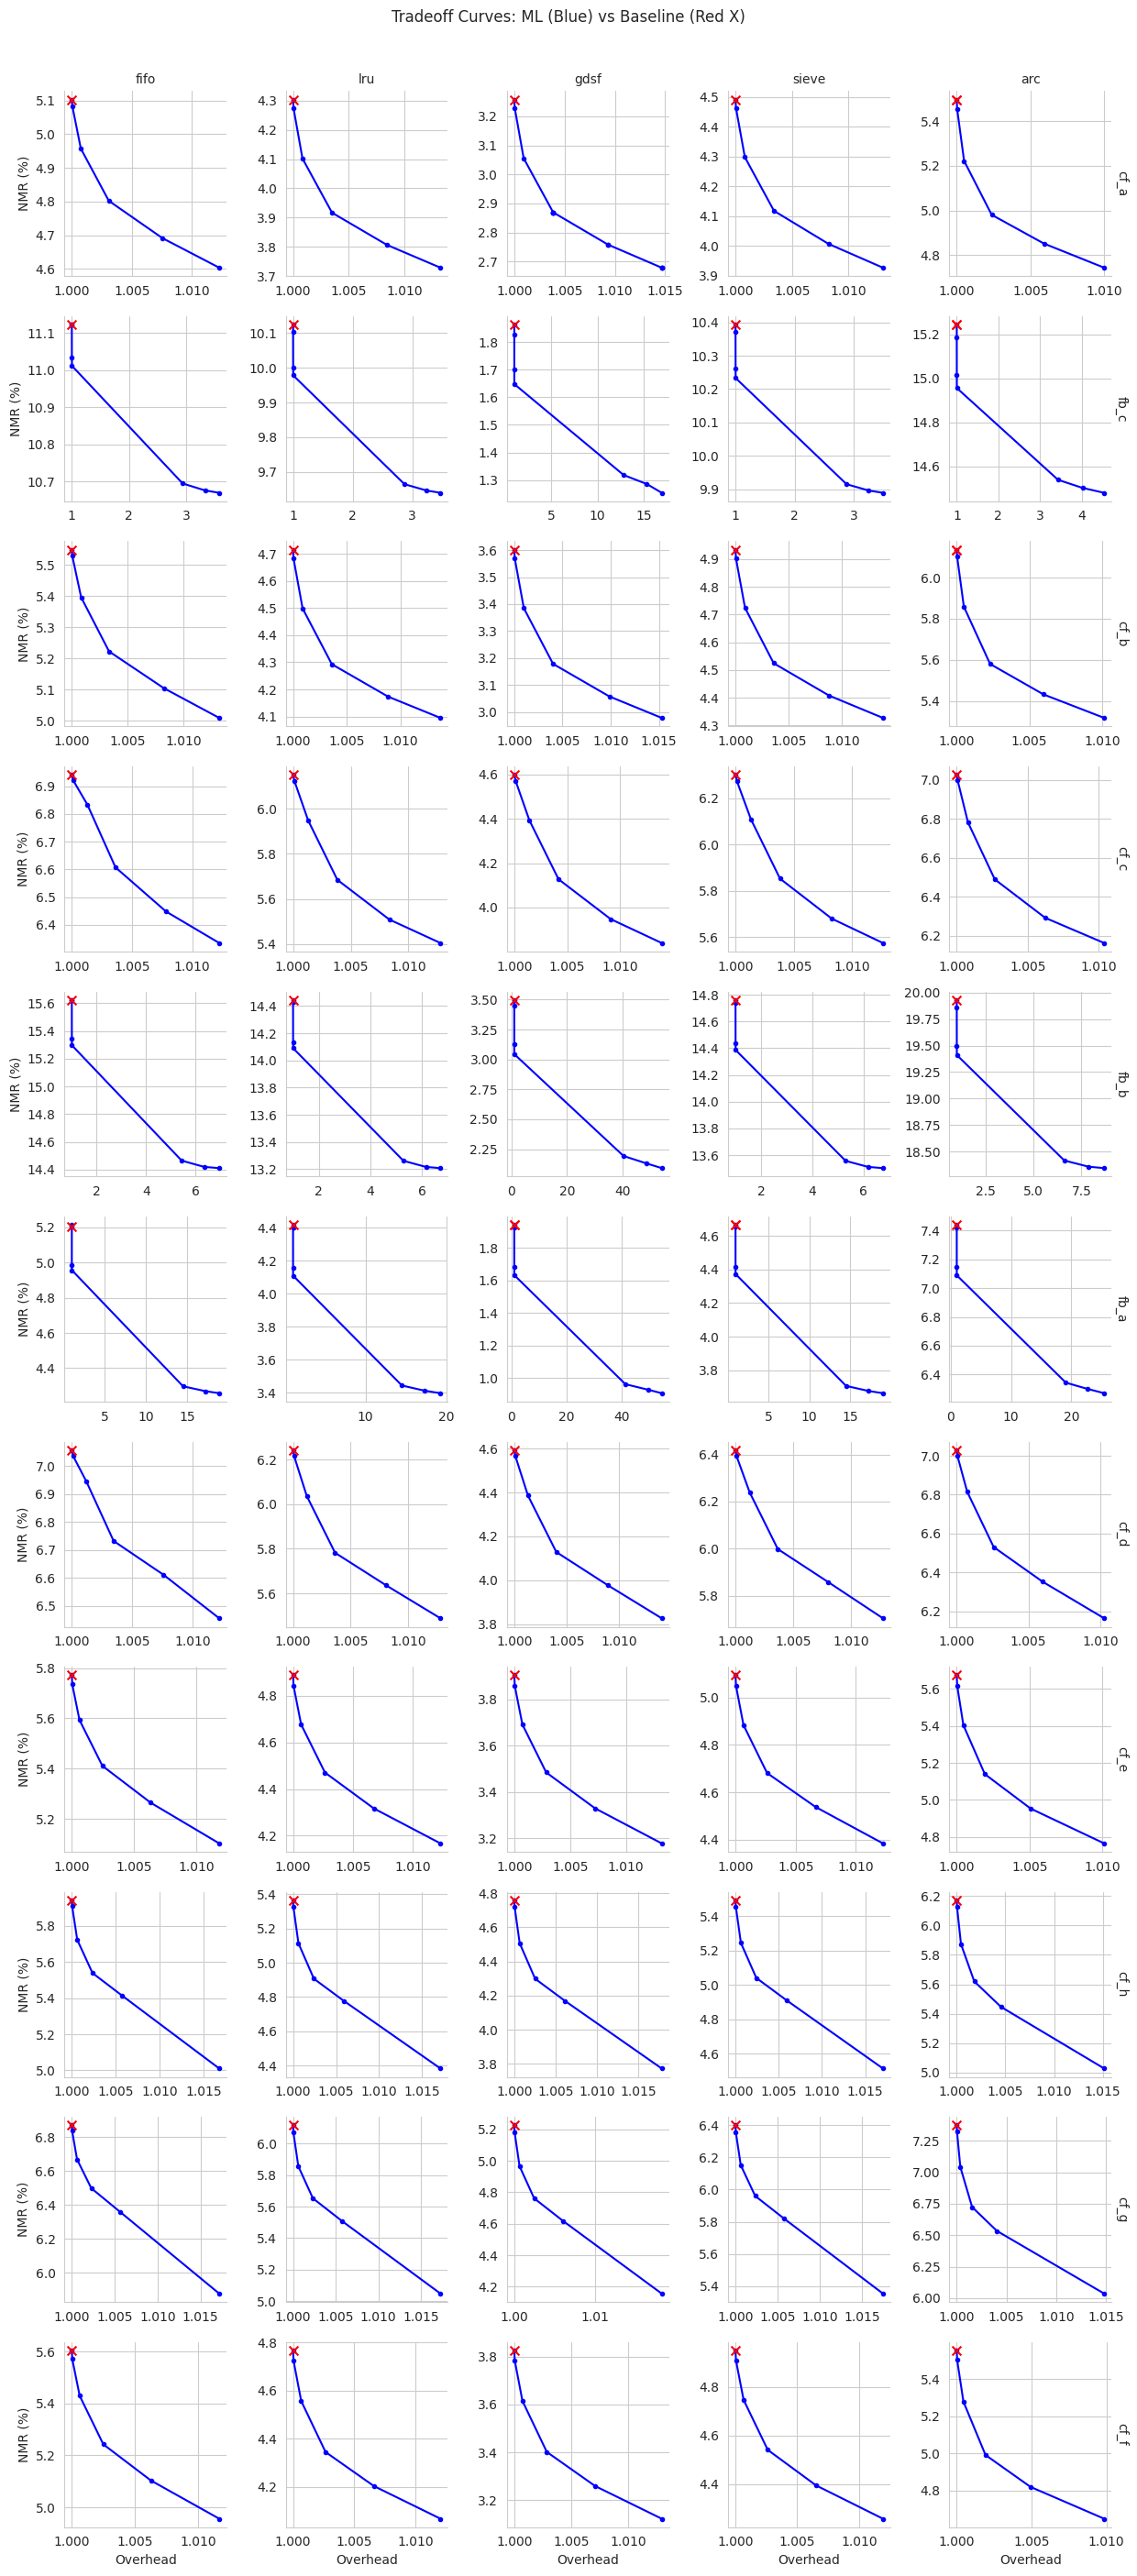

In [17]:
# --- Plot 4: Grid of Tradeoff Curves (ML Models) ---
# Create a grid with Trace (y) vs Cache Type (x)

# Filter for ML data
ml_df = df[df['mode'] == 'ml'].copy()
ml_df = ml_df.sort_values(by='amp_avg')

g = sns.FacetGrid(ml_df, row='in', col='cache_type', margin_titles=True, sharex=False, sharey=False, height=2.5, aspect=1)

# 1. Plot ML Curves
g.map(plt.plot, 'amp_avg', 'nmr', marker='.', linestyle='-', color='blue')

# 2. Plot Baseline Points (Reference)
def plot_baseline(data, **kwargs):
    if data.empty: return
    trace = data['in'].iloc[0]
    c_type = data['cache_type'].iloc[0]
    # Find baseline in the global 'df'
    base = df[(df['in'] == trace) & (df['cache_type'] == c_type) & (df['mode'] == 'never')]
    if not base.empty:
        plt.scatter(base['amp_avg'], base['nmr'], color='red', s=50, marker='x', zorder=10)

g.map_dataframe(plot_baseline)

g.set_axis_labels('Overhead', 'NMR (%)')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.suptitle('Tradeoff Curves: ML (Blue) vs Baseline (Red X)', y=1.02)

plt.show()

np.int64(22325884)

np.int64(19717173)

np.int64(24250247)

np.int64(18748425)

np.int64(11144070)

Text(0, 0.5, 'Absolute hit rate improvement (% points)')

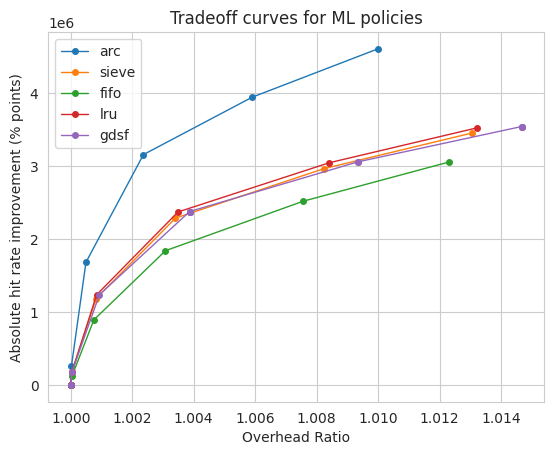

In [ ]:
mldf = df[(df['in'] == 'cf_a') & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
for ct in mldf['cache_type'].unique():
    nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == 'cf_a')]['optmiss'].values[0]
    subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
    subset = subset[subset['amp_avg'] < 1.1]
    plt.plot(subset['amp_avg'], nevermax - subset['optmiss'], marker='o', ms=4, linewidth=1, label=ct)
plt.legend()
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead Ratio')
plt.ylabel('Absolute hit rate improvement (% points)')

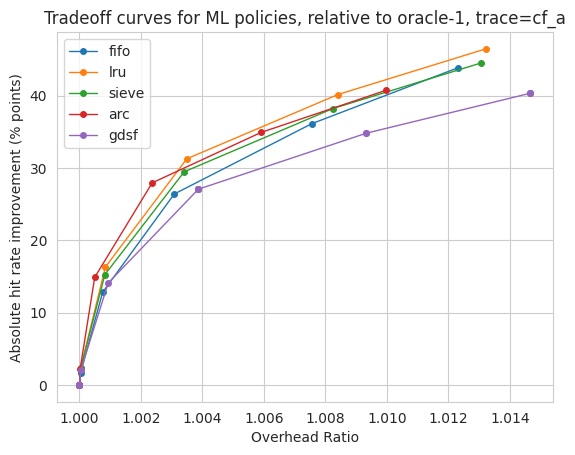

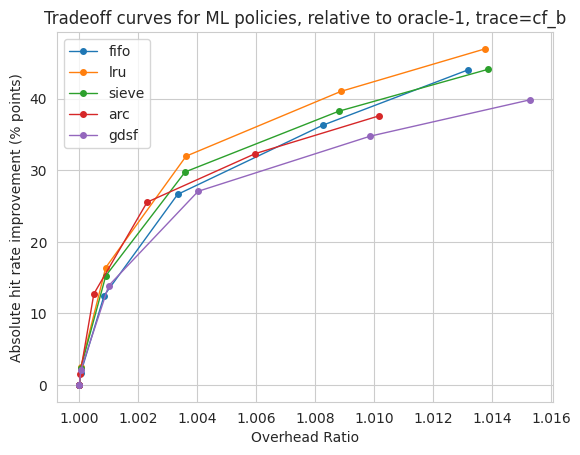

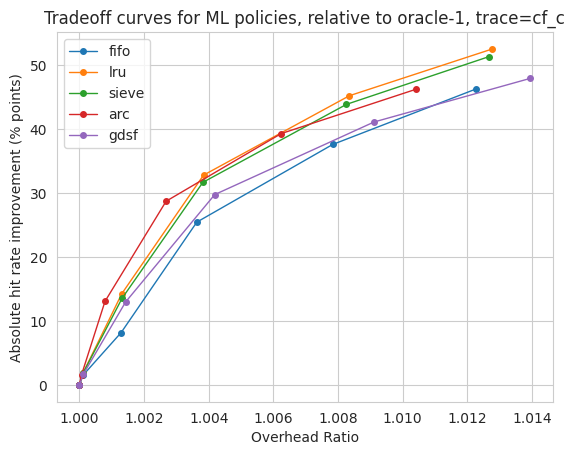

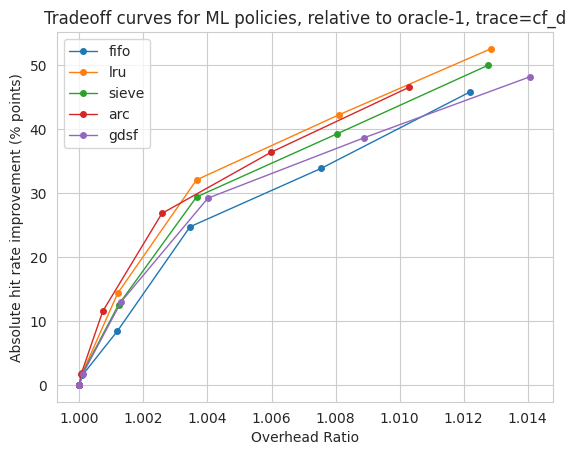

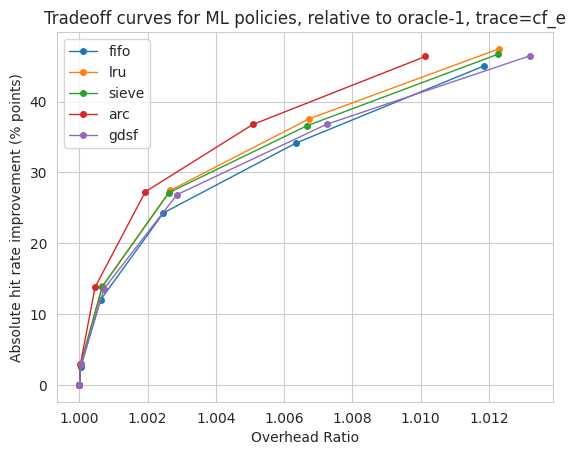

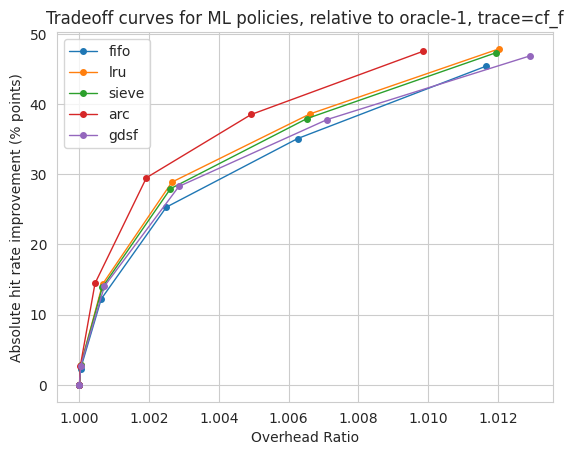

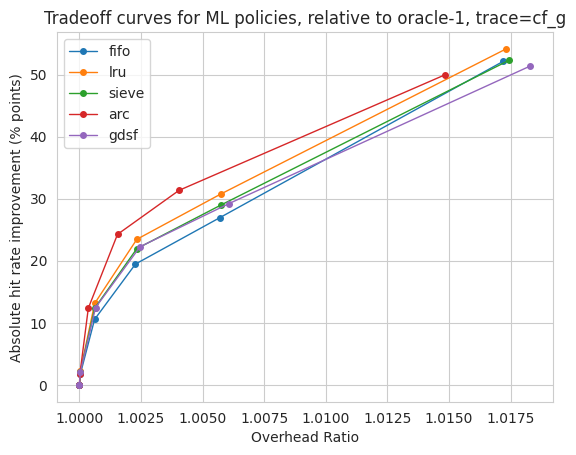

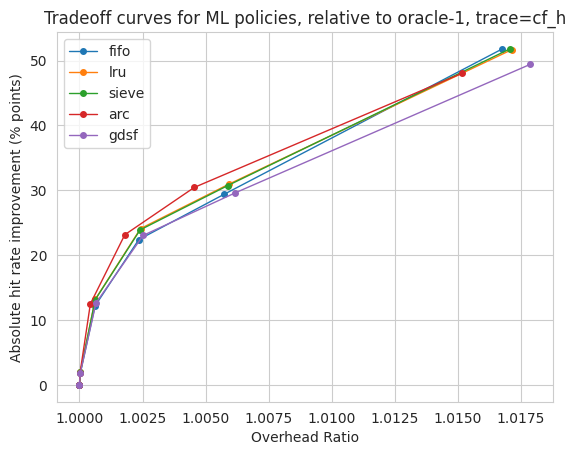

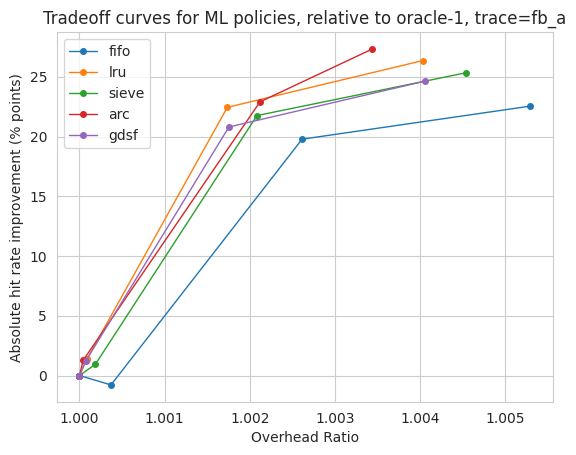

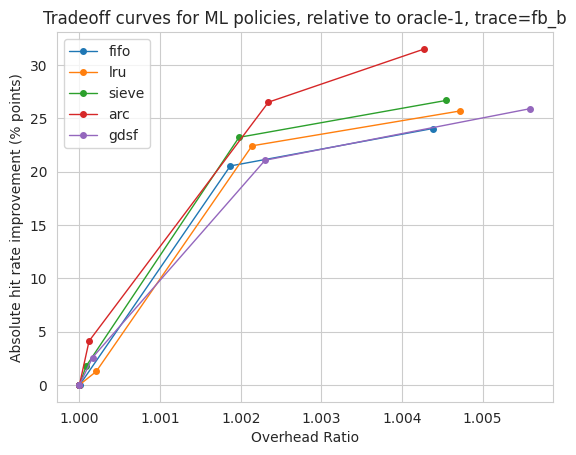

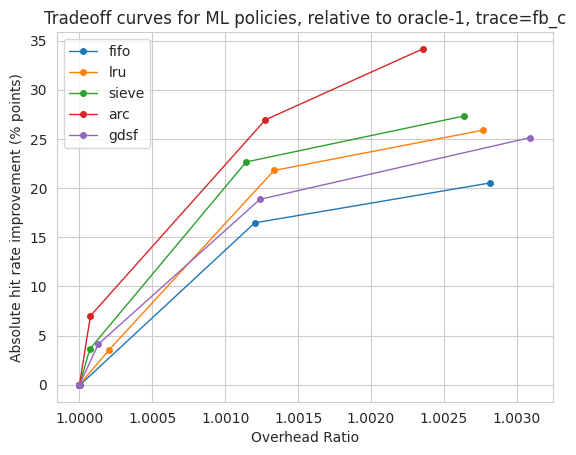

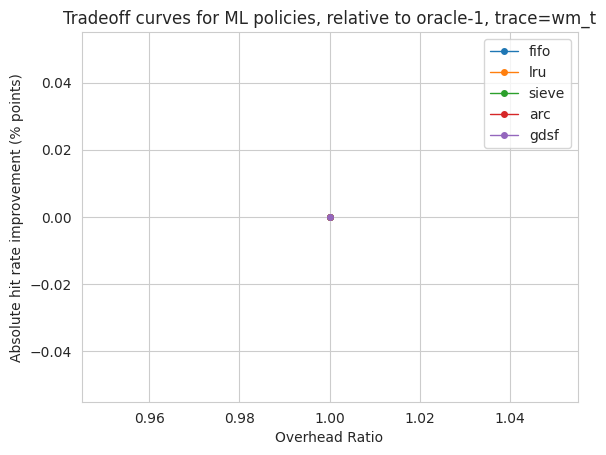

In [ ]:
for trace in sorted(df['in'].unique()):
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        subset = subset[subset['amp_avg'] < 1.3]
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        plt.plot(subset['amp_avg'], pc_oracle, marker='o', ms=4, linewidth=1, label=ct)
    plt.legend()
    plt.title(f'Tradeoff curves for ML policies, relative to oracle-1, trace={trace}')
    plt.xlabel('Overhead Ratio')
    plt.ylabel('Absolute hit rate improvement (% points)')
    plt.show()

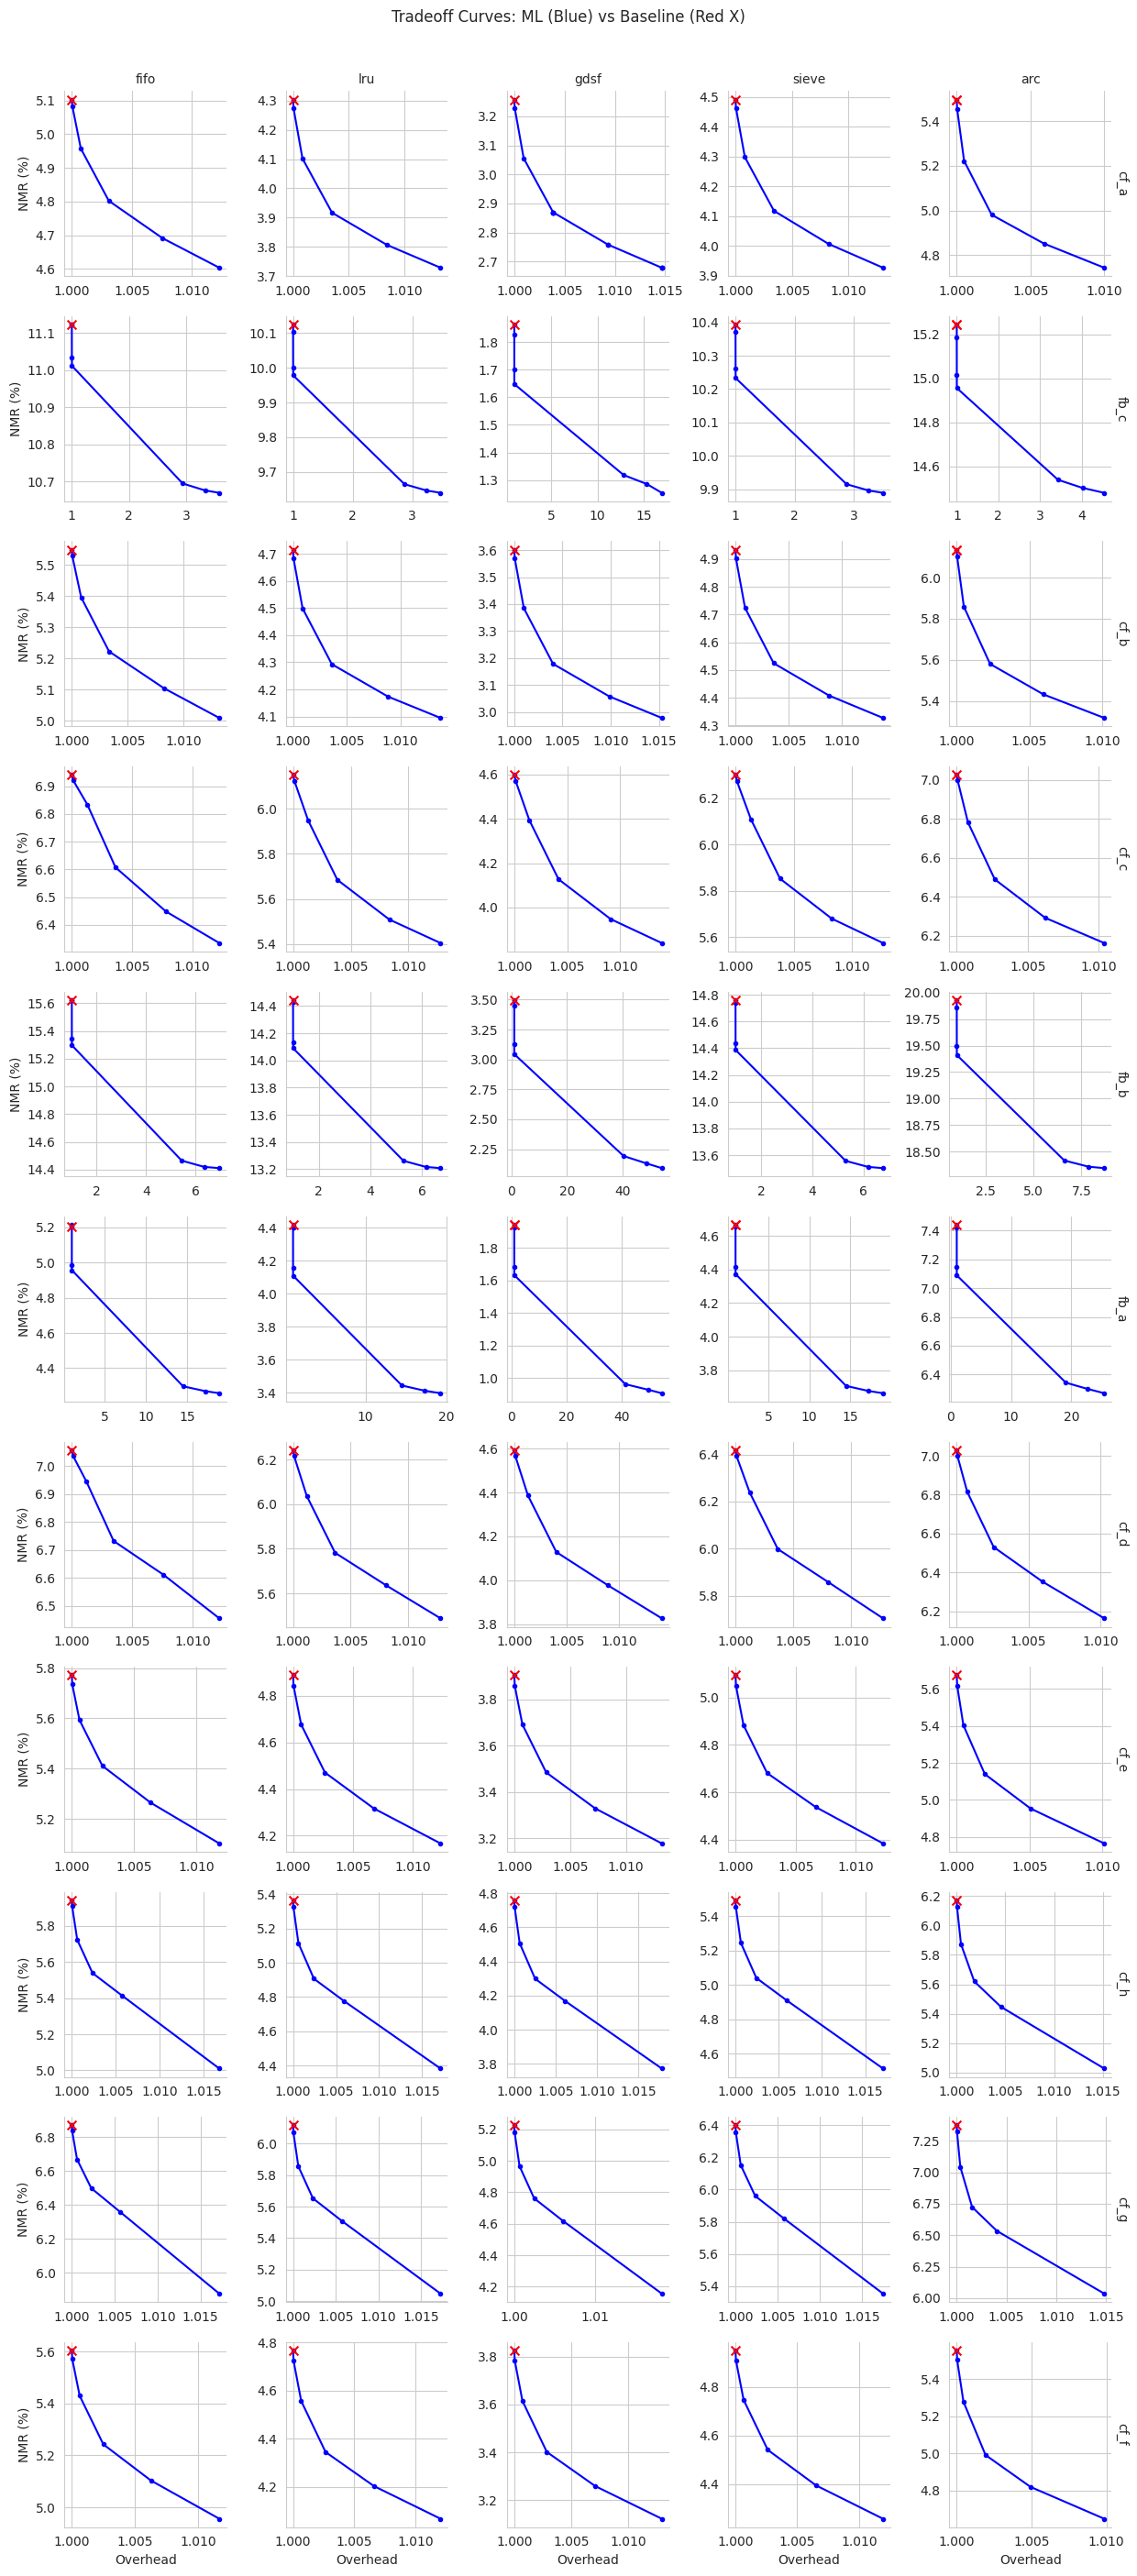

In [ ]:
# --- Plot 4: Grid of Tradeoff Curves (ML Models) ---
# Create a grid with Trace (y) vs Cache Type (x)

# Filter for ML data
ml_df = df[df['mode'] == 'ml'].copy()
ml_df = ml_df.sort_values(by='amp_avg')

g = sns.FacetGrid(ml_df, row='in', col='cache_type', margin_titles=True, sharex=False, sharey=False, height=2.5, aspect=1)

# 1. Plot ML Curves
g.map(plt.plot, 'amp_avg', 'nmr', marker='.', linestyle='-', color='blue')

# 2. Plot Baseline Points (Reference)
def plot_baseline(data, **kwargs):
    if data.empty: return
    trace = data['in'].iloc[0]
    c_type = data['cache_type'].iloc[0]
    # Find baseline in the global 'df'
    base = df[(df['in'] == trace) & (df['cache_type'] == c_type) & (df['mode'] == 'never')]
    if not base.empty:
        plt.scatter(base['amp_avg'], base['nmr'], color='red', s=50, marker='x', zorder=10)

g.map_dataframe(plot_baseline)

g.set_axis_labels('Overhead', 'NMR (%)')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.suptitle('Tradeoff Curves: ML (Blue) vs Baseline (Red X)', y=1.02)

plt.show()